In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns



def rdpg_sample_equiv(X):
    n = len(X)
    P = np.outer(X, X)
    U = np.zeros((n,n))
    triu_indices_N = np.triu_indices(n, k = 1)
    U[triu_indices_N] = np.random.rand(len(triu_indices_N[0]))
    U = U + U.T
    np.fill_diagonal(U, np.random.rand(n))

    A = (U < P).astype(int)
    np.fill_diagonal(A, 0)
    return A

def rdpg_sample_equiv_P(X):
    n = len(X)
    P = np.outer(X, X)
    U = np.zeros((n,n))
    triu_indices_N = np.triu_indices(n, k = 1)
    U[triu_indices_N] = np.random.rand(len(triu_indices_N[0]))
    U = U + U.T
    np.fill_diagonal(U, np.random.rand(n))

    A = (U < P).astype(int)
    np.fill_diagonal(A, 0)
    return P


def rdpg_sample(X_t):
   P = np.outer(X_t, X_t)
   np.fill_diagonal(P, 0) # remove self-loops
   A = np.random.rand(n, n) < P
   np.fill_diagonal(A, 0)
   A = np.triu(A, 1)
   A = A + A.T # so the graph is symmetric
   return A

def rdpg_sample_P(X_t):
   P = np.outer(X_t, X_t)
   np.fill_diagonal(P, 0) # remove self-loops
   A = np.random.rand(n, n) < P
   np.fill_diagonal(A, 0)
   A = np.triu(A, 1)
   A = A + A.T # so the graph is symmetric
   return P

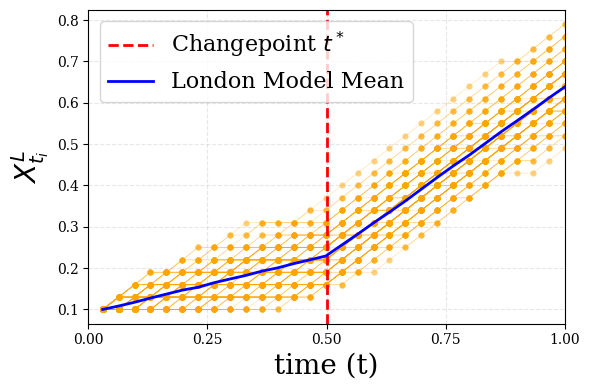

In [6]:
m = 30
c = 0.1
p = 0.3
q = 0.9
t_star = 0.5
t_star_m = int(t_star * m)-1

delta_m = q/m
n_paths = 100
grid = np.linspace(0.03, 1, m)

def simulate_london():
    X = np.zeros(m)
    X[0] = c
    for i in range(1, m):
        p_ti = p if i <= t_star_m else q
        if np.random.rand() < p_ti:
            X[i] = X[i-1] + delta_m
        else:
            X[i] = X[i-1]
    return X

london_paths = np.array([simulate_london() for _ in range(n_paths)])

plt.rcParams.update({
    "font.family": "serif",
    "font.sans-serif": ["DejaVu Sans"]
})

fig, ax = plt.subplots(figsize=(6, 4))
for path in london_paths:
    ax.scatter(grid, path, color='orange', alpha=0.5, lw=0, marker="o", s=20)
    ax.plot(grid, path, color='orange', alpha=0.3, lw=0.5)
ax.axvline(t_star, color='red', linestyle='--', lw=2, label='Changepoint $t^*$')
ax.plot(grid, london_paths.mean(axis=0), color='blue', lw=2, label='London Model Mean')
ax.set_xlabel('time (t)', fontsize=20)
ax.set_ylabel('$X^{L}_{t_i}$', fontsize=20)


ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_xlim(0, 1)

ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=16)

plt.tight_layout()
plt.savefig(str(n_paths) + "london_sample_paths_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_c="+str(c)+"_tstar="+ str(t_star)+".pdf", format="pdf")
np.save(str(n_paths) + "london_sample_paths_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_"+"_c="+str(c)+"_tstar="+ str(t_star)+".npy", london_paths)
plt.show()

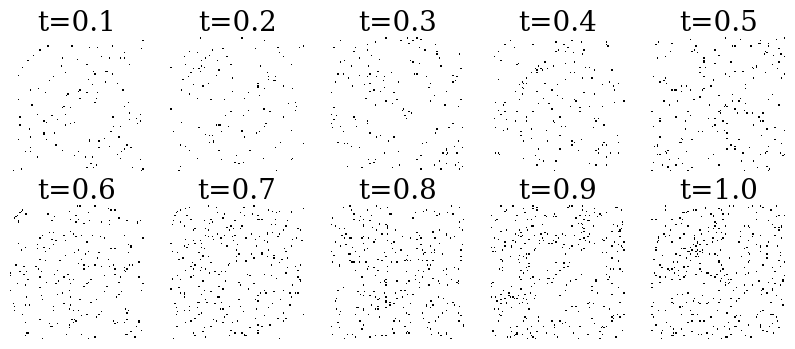

In [7]:
time_points = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
london_graphs = [rdpg_sample_equiv(london_paths[:, t]) for t in range(m)]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

mappable = None
for i in range(10):
    hm = sns.heatmap(london_graphs[i],
                     ax=axes[i],
                     cbar=False,
                     square=True,
                     cmap='Greys',
                     vmin=0, vmax=1)
    axes[i].set_title("t=" + str(time_points[i]/30), pad=5, fontsize = 20)
    axes[i].axis('off')
    if mappable is None:
        mappable = hm.get_children()[0]

np.save("adj"+str(n_paths) + "london_graphs_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_c="+str(c)+"_tstar="+ str(t_star)+".npy", london_graphs)
plt.savefig("adj"+str(n_paths) + "london_graphs_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_c="+str(c)+"_tstar="+ str(t_star)+".pdf", format="pdf")
plt.show()

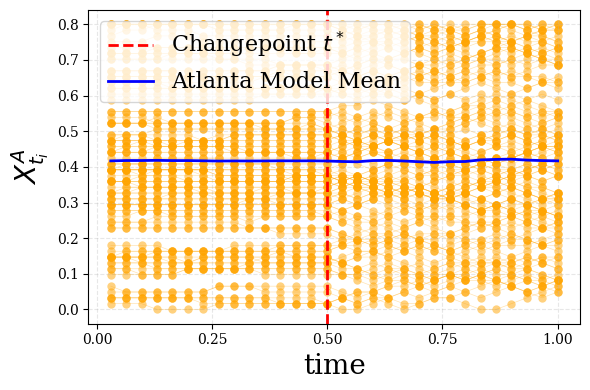

In [8]:
p = 0.05
q = 0.45
m=30
N=50
c=0.8
delta_N = c/(N-1)
time_grid = np.linspace(0.0, c, N)
grid = np.linspace(.03, 1, m)

t_star = 0.5
t_star_m = int(t_star * m)-1

n_paths = 100

def simulate_atlanta():
    X = np.zeros(m)
    X0_index = np.random.randint(1, N)
    X[0] = time_grid[X0_index]
    prev_index = X0_index
    curr_index = X0_index

    for i in range(1, m):
        p_ti = p if i <= t_star_m else q
        if prev_index == 0:
            if np.random.rand() < p_ti:
                curr_index = prev_index+1
            else:
                curr_index = prev_index
        elif prev_index == N-1:
            if np.random.rand() < p_ti:
                curr_index = prev_index-1
            else:
                curr_index = prev_index
        else:
            r = np.random.rand()
            if r < p_ti:
                curr_index = prev_index+1
            elif r < 2 * p_ti:
                curr_index = prev_index-1
            else:
                 curr_index = prev_index
        X[i] = time_grid[curr_index]
        prev_index = curr_index
    return X

atlanta_paths = np.array([simulate_atlanta() for _ in range(n_paths)])

plt.rcParams.update({
    "font.family": "serif",
    "font.sans-serif": ["DejaVu Sans"]
})

fig, ax = plt.subplots(figsize=(6, 4))
for path in atlanta_paths:
    ax.scatter(grid, path, color='orange', alpha=0.5, lw=0, marker="o")
    ax.plot(grid, path, color='orange', alpha=0.3, lw=0.5)

ax.axvline(t_star, color='red', linestyle='--', lw=2, label='Changepoint $t^*$')
ax.plot(grid, atlanta_paths.mean(axis=0), color='blue', lw=2, label='Atlanta Model Mean')
ax.set_xlabel('time', fontsize=20)
ax.set_ylabel('$X^{A}_{t_i}$', fontsize=20)


ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=16)

plt.tight_layout()
plt.savefig(str(n_paths) + "atlanta_sample_paths_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_c="+str(c)+"_N="+str(N)+"_tstar="+ str(t_star)+".pdf", format="pdf")
np.save(str(n_paths) + "atlanta_sample_paths_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_"+"_c="+str(c)+"_N="+str(N)+"_tstar="+ str(t_star)+".npy", atlanta_paths)

plt.show()


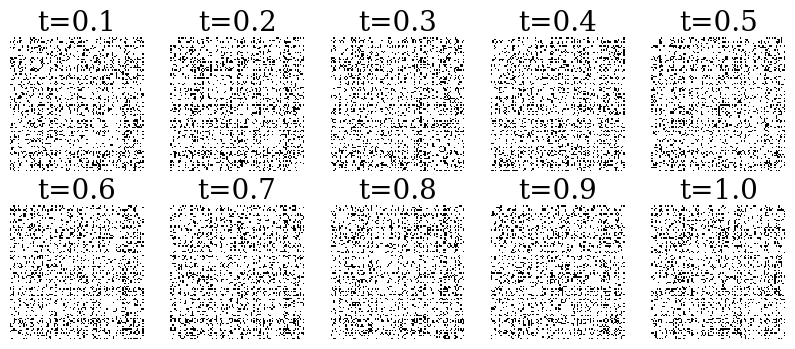

In [9]:
time_points = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
atlanta_graphs = [rdpg_sample_equiv(atlanta_paths[:, t]) for t in range(m)]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

mappable = None
for i in range(10):
    hm = sns.heatmap(atlanta_graphs[i],
                     ax=axes[i],
                     cbar=False,
                     square=True,
                     cmap='Greys',
                     vmin=0, vmax=1)
    axes[i].set_title("t=" + str(time_points[i]/30), pad=5, fontsize = 20)
    axes[i].axis('off')
    if mappable is None:
        mappable = hm.get_children()[0]


np.save("adj"+str(n_paths) + "atlanta_graphs_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_c="+str(c)+"_N="+str(N)+"_tstar="+ str(t_star)+".npy", atlanta_graphs)
plt.savefig("adj"+str(n_paths) + "atlanta_graphs_p="+str(p)+"_q=" +str(q)+"_m="+str(m)+"_c="+str(c)+"_N="+str(N)+"_tstar="+ str(t_star)+".pdf", format="pdf")
plt.show()

[np.int64(88), np.int64(130), np.int64(134), np.int64(148), np.int64(188), np.int64(220), np.int64(258), np.int64(276), np.int64(290), np.int64(288), np.int64(334), np.int64(364), np.int64(450), np.int64(484), np.int64(528), np.int64(640), np.int64(772), np.int64(1008), np.int64(1096), np.int64(1352), np.int64(1502), np.int64(1676), np.int64(1996), np.int64(2116), np.int64(2448), np.int64(2774), np.int64(2968), np.int64(3386), np.int64(3594), np.int64(4036)]
[np.float64(100.00000000000006), np.float64(117.50560000000004), np.float64(137.82760000000005), np.float64(162.81760000000003), np.float64(188.2384), np.float64(215.50240000000005), np.float64(236.23690000000005), np.float64(271.59040000000005), np.float64(302.06440000000003), np.float64(333.06250000000006), np.float64(371.3329000000001), np.float64(403.20640000000003), np.float64(445.21000000000004), np.float64(484.0000000000001), np.float64(525.7849000000001), np.float64(653.8249000000001), np.float64(795.8041000000003), np.floa

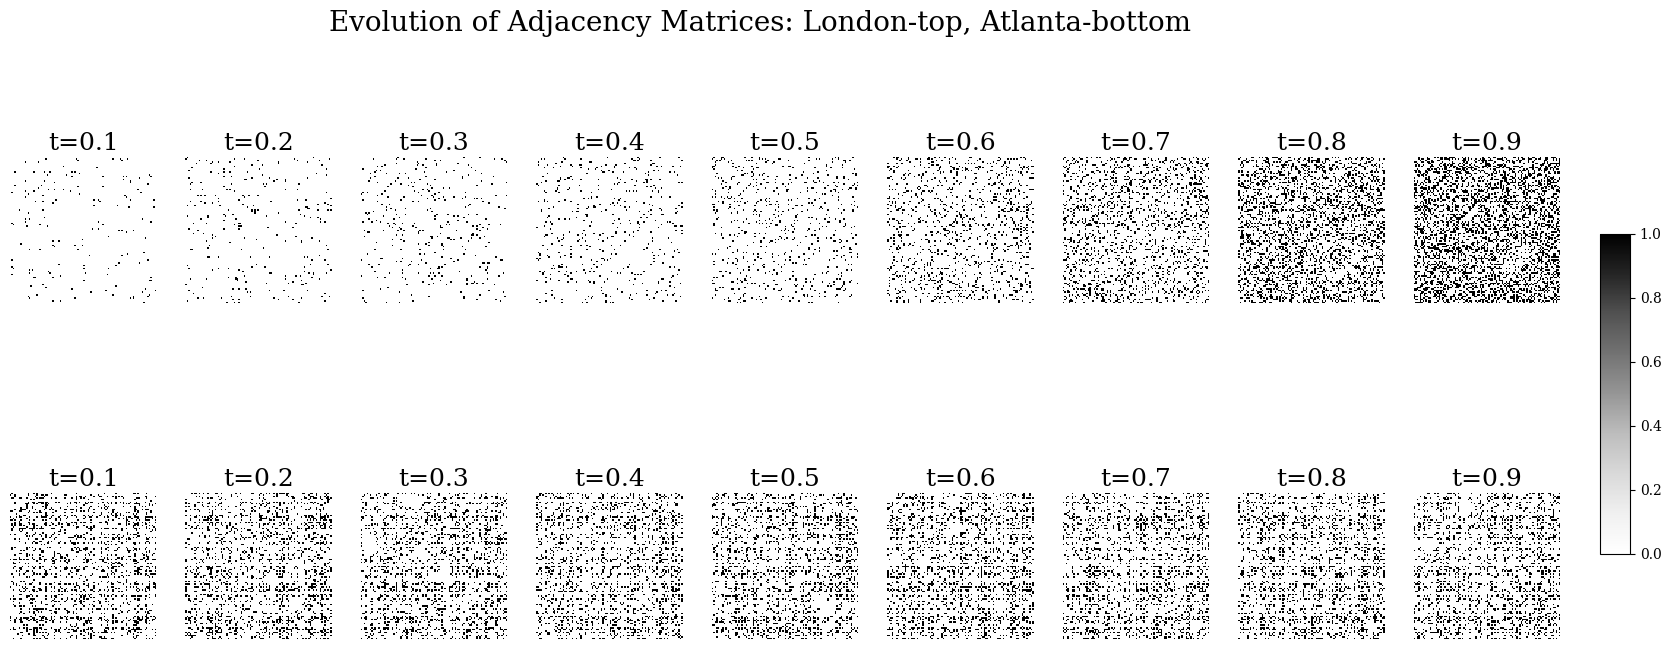

In [10]:
time_points = [3, 6, 9, 12,15, 18, 21, 24, 27]
fig, axes = plt.subplots(2, len(time_points), figsize=(20, 8))

london_graphs = [rdpg_sample_equiv(london_paths[:, t]) for t in range(m)]
atlanta_graphs = [rdpg_sample_equiv(atlanta_paths[:, t]) for t in range(m)]

london_graphs_P = [rdpg_sample_equiv_P(london_paths[:, t]) for t in range(m)]
atlanta_graphs_P = [rdpg_sample_equiv_P(atlanta_paths[:, t]) for t in range(m)]

london_graphs_sumA = [rdpg_sample_equiv(london_paths[:, t]).sum() for t in range(m)]
atlanta_graphs_sumA = [rdpg_sample_equiv(atlanta_paths[:, t]).sum() for t in range(m)]

london_graphs_sumP = [rdpg_sample_equiv_P(london_paths[:, t]).sum() for t in range(m)]
atlanta_graphs_sumP = [rdpg_sample_equiv_P(atlanta_paths[:, t]).sum() for t in range(m)]

print(london_graphs_sumA)
print(london_graphs_sumP)

print(atlanta_graphs_sumA)
print(atlanta_graphs_sumP)

mappable = None

for i, t in enumerate(time_points):
    hm = sns.heatmap(london_graphs[t],
                     ax=axes[0, i],
                     cbar=False,
                     square=True,
                     cmap='Greys',
                     vmin=0, vmax=1)
    axes[0, i].set_title(f't={t/m:.1f}', pad=5, fontsize =18)
    axes[0, i].axis('off')

    if mappable is None:
        mappable = hm.get_children()[0]

    sns.heatmap(atlanta_graphs[t],
                ax=axes[1, i],
                cbar=False,
                square=True,
                cmap='Greys',
                vmin=0, vmax=1)
    axes[1, i].set_title(f't={t/m:.1f}', pad=5, fontsize =18)
    axes[1, i].axis('off')

cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])

fig.colorbar(mappable, cax=cbar_ax)

#plt.savefig("time_series_graphs.pdf", format="pdf")
plt.suptitle('Evolution of Adjacency Matrices: London-top, Atlanta-bottom', y=0.98, fontsize=20)
#plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()